# RSO-656 — DIMM Telemetry Exploration

Investigate whether our DIMM seeing (`lsst.sal.DIMM.logevent_dimmMeasurement.fwhm`) is
corrupted by clouds / low flux, low wind, or other variables — and at what thresholds
the DIMM data should be considered unreliable.

See [`HANDOFF.md`](./HANDOFF.md) for state and [`FINDINGS.md`](./FINDINGS.md) for results.

**What the first run taught us (2026-07-01)** — our DIMM publishes a *thin* event:
- Dead/sentinel fields: `flux`=0, `nimg`=1, `scintL/R`=0, `r0`/`fwhmx`/`fwhmy`=−1. Don't use them.
- **Per-spot `fluxL`/`fluxR` are real** → transparency proxy `flux_proxy = fluxL + fluxR`.
- `DIMM.cloudSensor` and `DIMM.sky` **do not exist** in our EFD — no direct cloud stream.
- `fwhm` reaches ~42″ (unphysical); >5″ is treated as a failed measurement, not seeing.

**Plan of this notebook**
1. Pull `DIMM.logevent_dimmMeasurement`; inventory which fields are live; build `flux_proxy`.
2. Pull wind from `ESS.airFlow` (site "Weather tower airflow", salIndex 301).
3. Explore: seeing vs flux proxy, airmass; flag corrupted-fwhm regime.

Time-alignment with wind and the ConsDB `donut_blur_fwhm` comparison come next.

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib widget

In [2]:
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from astropy.time import Time

from lsst.summit.utils.efdUtils import (
    getEfdData,
    makeEfdClient,
    getDayObsStartTime,
    getDayObsEndTime,
)

# makeEfdClient is not working for now
from lsst_efd_client import EfdClient

warnings.filterwarnings("ignore")

PLOT_DIR = "plots"
os.makedirs(PLOT_DIR, exist_ok=True)

## 1. Configuration

Pick a `dayObs` range. Prefer a window that includes at least one known cloudy night so
the flux-drop signature is present. `dayObs` is an integer like `20260407`.

In [3]:
day_obs_begin = 20260119
day_obs_end = 20260407

## This is not working for now
# efd_client = makeEfdClient()

## Using the code below instead of makeEfdClient()
## The `output_mode="dataframe"` seems is required for it to work too.
efd_client = EfdClient("usdf_efd", output_mode="dataframe")

start_time = getDayObsStartTime(day_obs_begin)
end_time = getDayObsEndTime(day_obs_end)
print(f"Querying {start_time.isot}  ->  {end_time.isot}")

Querying 2026-01-19T12:00:00.000  ->  2026-04-08T12:00:00.000


## 2. DIMM measurements

`fwhm` is the seeing under scrutiny; `flux` is the cloud/transparency proxy at the heart
of Erik D.'s hypothesis. `secz` (airmass) and `nimg` are quality knobs.

In [4]:
dimm = getEfdData(
    efd_client,
    topic="lsst.sal.DIMM.logevent_dimmMeasurement",
    columns=[
        "fwhm",
        "fwhmx",
        "fwhmy",
        "flux",
        "fluxL",
        "fluxR",
        "scintL",
        "scintR",
        "strehlL",
        "strehlR",
        "secz",
        "nimg",
        "r0",
    ],
    begin=start_time,
    end=end_time,
)
print(f"{len(dimm)} DIMM measurements")
dimm.head()

28775 DIMM measurements


,fwhm,fwhmx,fwhmy,flux,fluxL,fluxR,scintL,scintR,strehlL,strehlR,secz,nimg,r0
2026-01-20 00:36:41.377236+00:00,1.049579,-1,-1,0,13507.0,11240.0,0,0,0.253,0.282,1.244,1,-1
2026-01-20 00:37:41.630488+00:00,1.051290,-1,-1,0,13578.0,11027.0,0,0,0.250,0.277,1.241,1,-1
2026-01-20 00:38:43.838943+00:00,0.973772,-1,-1,0,13448.0,10952.0,0,0,0.240,0.264,1.238,1,-1
2026-01-20 00:39:44.287677+00:00,1.001145,-1,-1,0,13350.0,10625.0,0,0,0.250,0.255,1.234,1,-1
2026-01-20 00:40:43.675218+00:00,0.997784,-1,-1,0,13598.0,10713.0,0,0,0.240,0.246,1.231,1,-1


In [5]:
# Quick look at the distributions and ranges of the key fields.
dimm[["fwhm", "flux", "scintL", "scintR", "secz", "nimg"]].describe()

,fwhm,flux,scintL,scintR,secz,nimg
count,28719.000000,28775.0,28775.0,28775.0,28743.000000,28775.0
mean,1.226294,0.0,0.0,0.0,1.108861,1.0
std,2.972332,0.0,0.0,0.0,0.078945,0.0
min,0.027817,0.0,0.0,0.0,1.002000,1.0
25%,0.754349,0.0,0.0,0.0,1.054000,1.0
50%,0.916576,0.0,0.0,0.0,1.101000,1.0
75%,1.106513,0.0,0.0,0.0,1.156000,1.0
max,41.693714,0.0,0.0,0.0,5.901000,1.0


In [6]:
# Transparency proxy: the combined `flux` is dead (all 0), but per-spot fluxes are real.
# Sum them for a total-flux proxy that stands in for the missing cloud sensor.
dimm["flux_proxy"] = dimm["fluxL"] + dimm["fluxR"]

# Flag physically implausible seeing. Atmospheric seeing is ~0.4-2"; a genuinely bad
# night reaches ~3-4". Values >> that are failed measurements (lost star, clouds, slewing),
# not real seeing -- we track them as a corruption signature rather than trusting them.
FWHM_MAX_PLAUSIBLE = 5.0  # arcsec
dimm["fwhm_ok"] = dimm["fwhm"].between(0.1, FWHM_MAX_PLAUSIBLE)

n_bad = (~dimm["fwhm_ok"]).sum()
print(f"{n_bad} / {len(dimm)} ({100 * n_bad / len(dimm):.1f}%) measurements have "
      f"fwhm outside [0.1, {FWHM_MAX_PLAUSIBLE}] arcsec")
dimm[["fwhm", "fluxL", "fluxR", "flux_proxy", "strehlL", "strehlR", "secz"]].describe()

315 / 28775 (1.1%) measurements have fwhm outside [0.1, 5.0] arcsec


,fwhm,fluxL,fluxR,flux_proxy,strehlL,strehlR,secz
count,28719.000000,28743.000000,28743.000000,28743.000000,28743.000000,28743.000000,28743.000000
mean,1.226294,31342.127405,30645.843718,61987.971123,0.238481,0.256660,1.108861
std,2.972332,37967.327291,38470.419349,75815.685800,0.068663,0.085491,0.078945
min,0.027817,880.000000,697.000000,1588.000000,0.000000,0.000000,1.002000
25%,0.754349,9741.000000,8811.000000,18421.000000,0.180000,0.187000,1.054000
50%,0.916576,10646.000000,10379.000000,20197.000000,0.242000,0.254000,1.101000
75%,1.106513,25749.000000,22225.500000,47285.500000,0.289000,0.321000,1.156000
max,41.693714,178544.000000,176038.000000,335857.000000,0.485000,0.514000,5.901000


## 2b. Field inventory — which columns are actually populated?

The first run exposed that our DIMM publishes a much thinner event than the SAL schema
advertises. Several fields are constant sentinels (`flux`=0, `nimg`=1, `r0`/`fwhmx`/`fwhmy`=−1,
`scintL`/`scintR`=0) and must **not** drive the analysis. Crucially, the *combined* `flux` is
dead but the **per-spot `fluxL`/`fluxR` are real** — so we can still build a transparency proxy
for Erik's cloud hypothesis. This cell classifies every numeric column as live vs dead so the
rest of the notebook only leans on real signal.

In [7]:
# Classify each numeric column as live (varies) or dead (constant sentinel).
def inventory(df, name):
    rows = []
    for col in df.columns:
        s = pd.to_numeric(df[col], errors="coerce")
        if s.notna().sum() == 0:
            rows.append((col, "non-numeric", "", "", ""))
            continue
        nun = s.nunique(dropna=True)
        rows.append((
            col,
            "DEAD" if nun <= 1 else "live",
            nun,
            f"{s.min():.4g}",
            f"{s.max():.4g}",
        ))
    out = pd.DataFrame(rows, columns=["column", "status", "n_unique", "min", "max"])
    print(f"=== {name}: {len(df)} rows ===")
    return out


inventory(dimm, "DIMM.logevent_dimmMeasurement")

=== DIMM.logevent_dimmMeasurement: 28775 rows ===


,column,status,n_unique,min,max
0,fwhm,live,8708,0.02782,41.69
1,fwhmx,DEAD,1,-1,-1
2,fwhmy,DEAD,1,-1,-1
3,flux,DEAD,1,0,0
4,fluxL,live,14324,880,1.785e+05
5,fluxR,live,13922,697,1.76e+05
6,scintL,DEAD,1,0,0
7,scintR,DEAD,1,0,0
8,strehlL,live,323,0,0.485
9,strehlR,live,391,0,0.514


## 3. Environmental context

- **Wind** — `lsst.sal.ESS.airFlow`. The site tower is `sensorName == "Weather tower airflow"`
  (`salIndex == 301`); other sensors (AuxTel, WiFi test units, dome louvers) are not the DIMM's
  ambient wind. Known rule of thumb: DIMM unreliable for wind **< 4 m/s**.
- **Clouds / transparency** — the DIMM's `cloudSensor` and `sky` topics **do not exist in our
  EFD** (`ValueError: not in EFD schema`). We therefore proxy transparency with the DIMM's own
  **`flux_proxy = fluxL + fluxR`** (built above) and the Strehl ratios. If an independent cloud
  reference is needed, the ConsDB comparison notebook (`donut_blur_atm_fwhm`) is the fallback.

In [8]:
wind = getEfdData(
    efd_client,
    topic="lsst.sal.ESS.airFlow",
    columns=["salIndex", "sensorName", "speed", "maxSpeed", "direction"],
    begin=start_time,
    end=end_time,
)
# Keep only the site weather tower; drop AuxTel / WiFi-test / dome-louver anemometers.
wind = wind[wind["sensorName"] == "Weather tower airflow"]
print(f"{len(wind)} weather-tower wind samples")
wind[["speed", "maxSpeed", "direction"]].describe()

5287514 weather-tower wind samples


,speed,maxSpeed,direction
count,5.287514e+06,5.287514e+06,5.287514e+06
mean,4.226964e+00,4.333242e+00,1.041954e+02
std,2.933818e+00,2.981405e+00,1.110069e+02
min,0.000000e+00,0.000000e+00,3.186647e-04
25%,1.918200e+00,2.085000e+00,1.914501e+01
50%,3.753000e+00,3.919800e+00,3.859500e+01
75%,5.921400e+00,6.088200e+00,1.830000e+02
max,2.176740e+01,2.176740e+01,3.600000e+02


> **Negative result (2026-07-01):** `lsst.sal.DIMM.cloudSensor` and `lsst.sal.DIMM.sky` both
> raise `ValueError: Topic ... not in EFD schema` — our DIMM does not publish them. There is no
> direct cloud/sky-state stream to join, so the transparency test relies on `flux_proxy` and
> Strehl (above). Record this limitation in `FINDINGS.md`.

## 4. First look: does low flux track corrupted seeing?

The core hypothesis: under clouds the DIMM loses light — **`flux_proxy` drops** — and reported
`fwhm` becomes unreliable (Erik D.'s claim is that it reads *artificially low*). We plot seeing
vs the flux proxy (log-x, since flux spans decades) and vs airmass, colouring the physically
implausible `fwhm` (> 5″) points so any low-flux corruption regime stands out. `nimg` and the
combined `flux` are dropped — both are dead constants for our DIMM.

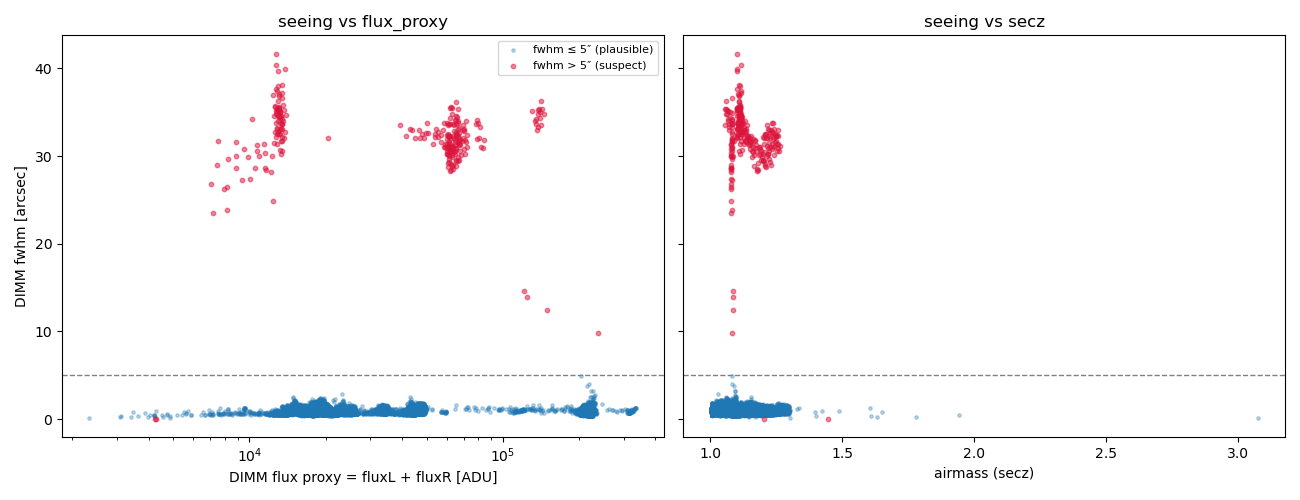

In [9]:
ok = dimm["fwhm_ok"]
bad = ~ok

panels = [
    ("flux_proxy", "DIMM flux proxy = fluxL + fluxR [ADU]", True),
    ("secz", "airmass (secz)", False),
]

fig, axes = plt.subplots(1, len(panels), figsize=(13, 5), sharey=True)

for ax, (xcol, xlabel, logx) in zip(axes, panels):
    ax.scatter(dimm.loc[ok, xcol], dimm.loc[ok, "fwhm"], s=6, alpha=0.3,
               label="fwhm ≤ 5″ (plausible)")
    ax.scatter(dimm.loc[bad, xcol], dimm.loc[bad, "fwhm"], s=10, alpha=0.5,
               color="crimson", label="fwhm > 5″ (suspect)")
    if logx:
        ax.set_xscale("log")
    ax.axhline(FWHM_MAX_PLAUSIBLE, ls="--", color="grey", lw=1)
    ax.set_xlabel(xlabel)
    ax.set_title(f"seeing vs {xcol}")

axes[0].set_ylabel("DIMM fwhm [arcsec]")
axes[0].legend(loc="upper right", fontsize=8)

fig.tight_layout()
fig.savefig(f"{PLOT_DIR}/dimm_seeing_vs_context_{day_obs_begin}_{day_obs_end}.png", dpi=120)
plt.show()

## 5. Quantitative test — align wind, then bin seeing vs flux & wind

`flux_proxy` varies over a wide range, so the cloud test is viable. We now:
1. Time-align the 1 Hz wind onto each ~1-min DIMM measurement with `merge_asof`
   (nearest sample within a tolerance), giving one wind speed per seeing value.
2. Bin `fwhm` against `flux_proxy` and against wind speed, and report — per bin — the
   median seeing, its scatter (robust σ via the IQR), and the **fraction of suspect
   (`fwhm > 5″`) measurements**. The hypotheses predict: at **low flux** the suspect
   fraction rises and/or the median drifts; at **wind < 4 m/s** the seeing scatter blows up.

In [10]:
# Time-align wind onto each DIMM measurement. Both are tz-aware UTC DatetimeIndex.
# merge_asof needs sorted keys and matches each DIMM row to the nearest wind sample.
dimm_sorted = dimm.sort_index()
wind_sorted = wind.sort_index()

merged = pd.merge_asof(
    dimm_sorted,
    wind_sorted[["speed", "maxSpeed"]].rename(columns={"speed": "wind_speed",
                                                       "maxSpeed": "wind_max"}),
    left_index=True,
    right_index=True,
    direction="nearest",
    tolerance=pd.Timedelta("2min"),
)

n_wind = merged["wind_speed"].notna().sum()
print(f"{n_wind} / {len(merged)} DIMM measurements matched a wind sample within 2 min")
merged[["fwhm", "flux_proxy", "wind_speed", "wind_max", "secz", "fwhm_ok"]].describe()

28775 / 28775 DIMM measurements matched a wind sample within 2 min


,fwhm,flux_proxy,wind_speed,wind_max,secz
count,28719.000000,28743.000000,28775.000000,28775.000000,28743.000000
mean,1.226294,61987.971123,3.447556,3.517889,1.108861
std,2.972332,75815.685800,2.524064,2.564135,0.078945
min,0.027817,1588.000000,0.000000,0.000000,1.002000
25%,0.754349,18421.000000,1.584600,1.584600,1.054000
50%,0.916576,20197.000000,3.085800,3.085800,1.101000
75%,1.106513,47285.500000,4.753800,4.920600,1.156000
max,41.693714,335857.000000,15.929400,16.596600,5.901000


In [11]:
# Bin fwhm behaviour against a driver variable. Robust sigma = IQR / 1.349 (Gaussian-
# equivalent), which is insensitive to the >5" corruption tail. suspect_frac is the
# fraction of measurements in the bin flagged as failed (fwhm > 5").
def bin_seeing(df, xcol, bins, xlabel):
    d = df[df[xcol].notna()].copy()
    d["_bin"] = pd.cut(d[xcol], bins=bins)
    g = d.groupby("_bin", observed=True)
    q1 = g["fwhm"].quantile(0.25)
    q3 = g["fwhm"].quantile(0.75)
    out = pd.DataFrame({
        "n": g.size(),
        "fwhm_median": g["fwhm"].median(),
        "fwhm_sigma_robust": (q3 - q1) / 1.349,
        "suspect_frac": g.apply(lambda x: (~x["fwhm_ok"]).mean(), include_groups=False),
    })
    out.index.name = xlabel
    return out


# Flux bins: log-spaced across the observed range (flux_proxy spans decades).
fp = merged["flux_proxy"].replace(0, np.nan).dropna()
flux_bins = np.geomspace(fp.min(), fp.max(), 9)
by_flux = bin_seeing(merged, "flux_proxy", flux_bins, "flux_proxy [ADU]")
print("=== seeing vs flux_proxy ===")
by_flux

=== seeing vs flux_proxy ===


,n,fwhm_median,fwhm_sigma_robust,suspect_frac
flux_proxy [ADU],,,,
"(1588.0, 3101.084]",21,0.156525,0.027215,0.904762
"(3101.084, 6055.869]",32,0.462787,0.147281,0.187500
"(6055.869, 11826.043]",133,0.689636,0.402478,0.180451
"(11826.043, 23094.175]",15401,0.909813,0.281464,0.004675
"(23094.175, 45098.847]",4297,0.880301,0.269627,0.000931
"(45098.847, 88070.087]",3154,0.991395,0.238116,0.043754
"(88070.087, 171985.335]",134,1.058967,0.169104,0.134328
"(171985.335, 335857.0]",5570,0.911648,0.204267,0.000180


In [12]:
# Wind bins, with an explicit edge at 4 m/s to test the known unreliability rule.
wind_bins = [0, 2, 4, 6, 8, 10, 15, np.inf]
by_wind = bin_seeing(merged, "wind_speed", wind_bins, "wind_speed [m/s]")
print("=== seeing vs wind_speed (edge at 4 m/s) ===")
by_wind

=== seeing vs wind_speed (edge at 4 m/s) ===


,n,fwhm_median,fwhm_sigma_robust,suspect_frac
wind_speed [m/s],,,,
"(0.0, 2.0]",7454,1.052487,0.283711,0.012074
"(2.0, 4.0]",9701,0.890178,0.219301,0.014844
"(4.0, 6.0]",5689,0.816970,0.168184,0.002988
"(6.0, 8.0]",2495,0.867727,0.232495,0.003607
"(8.0, 10.0]",1034,0.961072,0.276529,0.027079
"(10.0, 15.0]",632,1.045464,0.267484,0.003165
"(15.0, inf]",14,0.966089,0.204896,0.000000


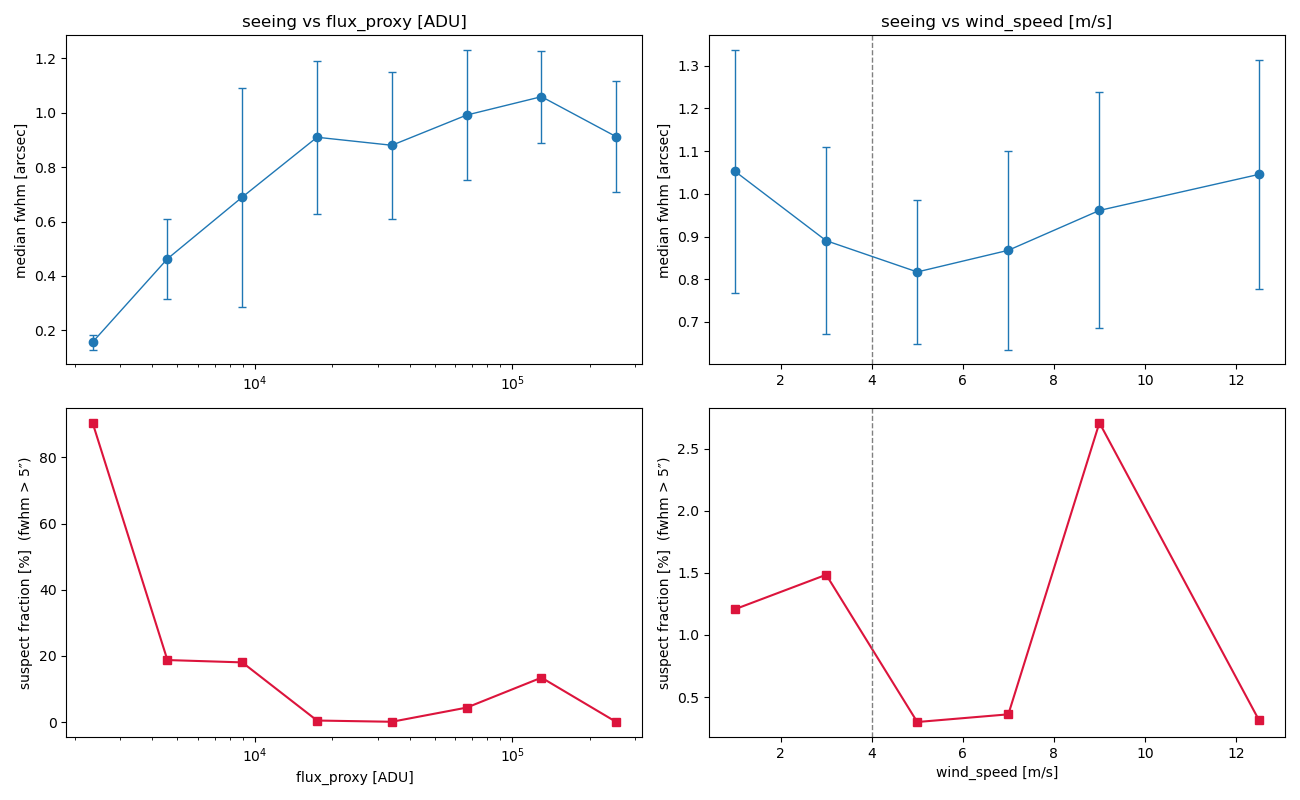

In [13]:
# Visualise both drivers: median seeing (+ robust sigma band) and the suspect fraction.
fig, axes = plt.subplots(2, 2, figsize=(13, 8))


def plot_driver(ax_med, ax_sus, table, logx, xlabel):
    x = [iv.mid for iv in table.index]
    ax_med.errorbar(x, table["fwhm_median"], yerr=table["fwhm_sigma_robust"],
                    marker="o", capsize=3, lw=1)
    ax_med.set_ylabel("median fwhm [arcsec]")
    ax_med.set_title(f"seeing vs {xlabel}")
    ax_sus.plot(x, 100 * table["suspect_frac"], marker="s", color="crimson")
    ax_sus.set_ylabel("suspect fraction [%]  (fwhm > 5″)")
    ax_sus.set_xlabel(xlabel)
    for ax in (ax_med, ax_sus):
        if logx:
            ax.set_xscale("log")


plot_driver(axes[0, 0], axes[1, 0], by_flux, True, "flux_proxy [ADU]")
plot_driver(axes[0, 1], axes[1, 1], by_wind, False, "wind_speed [m/s]")
axes[1, 1].axvline(4, ls="--", color="grey", lw=1)  # known 4 m/s rule
axes[0, 1].axvline(4, ls="--", color="grey", lw=1)

fig.tight_layout()
fig.savefig(f"{PLOT_DIR}/dimm_seeing_vs_flux_wind_{day_obs_begin}_{day_obs_end}.png", dpi=120)
plt.show()

## 6. Next

- Read off the flux and wind thresholds from the tables/figure above (where does
  `suspect_frac` climb / the median seeing drift?) and record them in `FINDINGS.md` §5.
- **ConsDB cross-check (separate notebook):** join DIMM `fwhm` to
  `donut_blur_atm_fwhm = sqrt(donut_blur_fwhm² − CAM_FWHM²)` on time and look for the regime
  where DIMM reads low while donut blur stays high — the definitive cloud signature, since
  it uses an independent instrument.
- Zoom into one known cloudy night: overplot `fwhm`, `flux_proxy`, and `wind_speed` vs time
  to see the flux-drop → seeing-corruption sequence directly.